# **Customer Behavioral Segmentation.**

We are going to conduct an RFM (Recency, Frequency, Monetary) analysis and segmentation of customers into groups, according to these signals.

## **Load Data.**

In [1]:
import os
import pandas as pd
import numpy as np

DATASETS_PATH = os.getenv("DATASETS_PATH")
DATASETS_PATH = DATASETS_PATH + "/CustomerSegmentation/"

df = pd.read_excel(DATASETS_PATH + "online_retail_II.xlsx", sheet_name=None)

data_df = pd.concat(df.values(), ignore_index=True)

print("Data: ")
print(data_df)

Data: 
        Invoice StockCode                          Description  Quantity  \
0        489434     85048  15CM CHRISTMAS GLASS BALL 20 LIGHTS        12   
1        489434    79323P                   PINK CHERRY LIGHTS        12   
2        489434    79323W                  WHITE CHERRY LIGHTS        12   
3        489434     22041         RECORD FRAME 7" SINGLE SIZE         48   
4        489434     21232       STRAWBERRY CERAMIC TRINKET BOX        24   
...         ...       ...                                  ...       ...   
1067366  581587     22899         CHILDREN'S APRON DOLLY GIRL          6   
1067367  581587     23254        CHILDRENS CUTLERY DOLLY GIRL          4   
1067368  581587     23255      CHILDRENS CUTLERY CIRCUS PARADE         4   
1067369  581587     22138        BAKING SET 9 PIECE RETROSPOT          3   
1067370  581587      POST                              POSTAGE         1   

                InvoiceDate  Price  Customer ID         Country  
0       2009-1

## **Calculate FRM signals.**

Define reference date.

In [2]:
reference_date = data_df["InvoiceDate"].max() + pd.Timedelta(days=1)
print(reference_date)

2011-12-10 12:50:00


Calculate **monetary** value.

In [3]:
data_df["Revenue"] = data_df["Quantity"] * data_df["Price"]

monetary = data_df.groupby("Customer ID")["Revenue"].sum()

print(monetary)

Customer ID
12346.0     -64.68
12347.0    5633.32
12348.0    2019.40
12349.0    4404.54
12350.0     334.40
            ...   
18283.0    2736.65
18284.0     436.68
18285.0     427.00
18286.0    1188.43
18287.0    4177.89
Name: Revenue, Length: 5942, dtype: float64


In [4]:
print(data_df[data_df["Quantity"] < 0].head())

     Invoice StockCode                    Description  Quantity  \
178  C489449     22087       PAPER BUNTING WHITE LACE       -12   
179  C489449    85206A   CREAM FELT EASTER EGG BASKET        -6   
180  C489449     21895  POTTING SHED SOW 'N' GROW SET        -4   
181  C489449     21896             POTTING SHED TWINE        -6   
182  C489449     22083     PAPER CHAIN KIT RETRO SPOT       -12   

            InvoiceDate  Price  Customer ID    Country  Revenue  
178 2009-12-01 10:33:00   2.95      16321.0  Australia    -35.4  
179 2009-12-01 10:33:00   1.65      16321.0  Australia     -9.9  
180 2009-12-01 10:33:00   4.25      16321.0  Australia    -17.0  
181 2009-12-01 10:33:00   2.10      16321.0  Australia    -12.6  
182 2009-12-01 10:33:00   2.95      16321.0  Australia    -35.4  


Negative values in revenue are due to refunds and cancelations.

Let's delete transactions with negative values. 

In [5]:
data_df = data_df[data_df["Quantity"] > 0]
data_df = data_df[data_df["Price"] > 0]
data_df = data_df.dropna(subset=["Customer ID"])

In [6]:
data_df["Revenue"] = data_df["Quantity"] * data_df["Price"]

monetary = data_df.groupby("Customer ID")["Revenue"].sum()

print(monetary)

Customer ID
12346.0    77556.46
12347.0     5633.32
12348.0     2019.40
12349.0     4428.69
12350.0      334.40
             ...   
18283.0     2736.65
18284.0      461.68
18285.0      427.00
18286.0     1296.43
18287.0     4182.99
Name: Revenue, Length: 5878, dtype: float64


Calculate **frequency** value (how many purchases a customer made).

In [7]:
data_df["Customer ID"] = data_df["Customer ID"].astype("int64")
frequency = data_df.groupby("Customer ID")["Invoice"].nunique()

print(frequency)

Customer ID
12346    12
12347     8
12348     5
12349     4
12350     1
         ..
18283    22
18284     1
18285     1
18286     2
18287     7
Name: Invoice, Length: 5878, dtype: int64


Calculate **recency** value.

In [8]:
last_purchase = data_df.groupby("Customer ID")["InvoiceDate"].max()

recency = (reference_date - last_purchase).dt.days

print(recency)

Customer ID
12346    326
12347      2
12348     75
12349     19
12350    310
        ... 
18283      4
18284    432
18285    661
18286    477
18287     43
Name: InvoiceDate, Length: 5878, dtype: int64


Combine into **RFM** table.

In [9]:
rfm = pd.DataFrame({
    "Recency": recency,
    "Frequency": frequency,
    "Monetary": monetary
})

print(rfm)

             Recency  Frequency  Monetary
Customer ID                              
12346            326         12  77556.46
12347              2          8   5633.32
12348             75          5   2019.40
12349             19          4   4428.69
12350            310          1    334.40
...              ...        ...       ...
18283              4         22   2736.65
18284            432          1    461.68
18285            661          1    427.00
18286            477          2   1296.43
18287             43          7   4182.99

[5878 rows x 3 columns]


## **Prepare columns for segmentation.**

In [10]:
import numpy as np
from sklearn.preprocessing import StandardScaler
from matplotlib import pyplot as plt

# log transform
rfm_log = np.log1p(rfm)

# scaling
scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(rfm_log)


Let's plot initial data and compare the distributions with scaled dataframe.

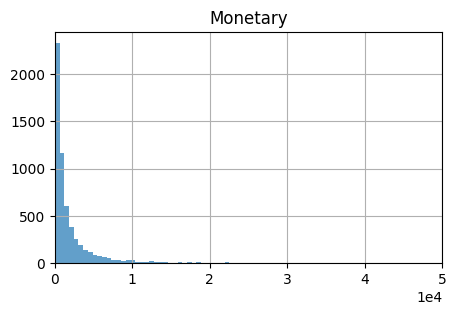

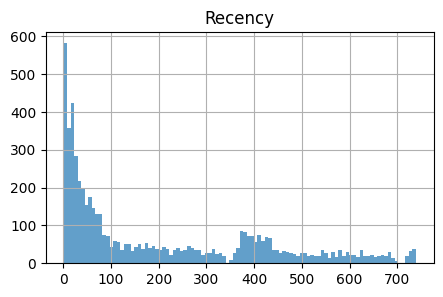

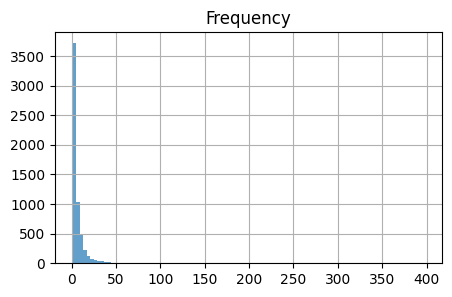

In [11]:
rfm["Monetary"].hist(figsize=(5,3), bins=1000, alpha = 0.7)
plt.xlim(0, 50000)
plt.title("Monetary")
for ax in plt.gcf().axes:
    ax.ticklabel_format(axis='x', style='sci', scilimits=(0,0))
plt.show()

rfm["Recency"].hist(figsize=(5,3), bins=100, alpha = 0.7)
plt.title("Recency")
plt.show()

rfm["Frequency"].hist(figsize=(5,3), bins=100, alpha = 0.7)
plt.title("Frequency")
plt.show()

And now we plot the scaled data.

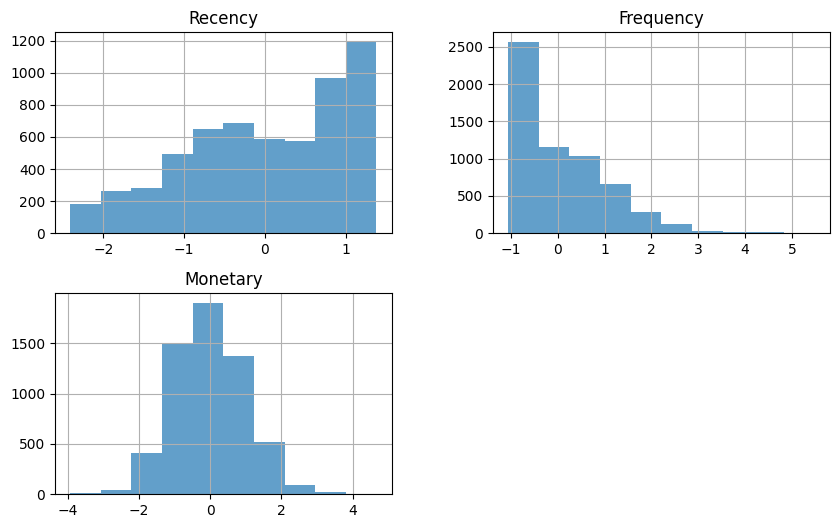

In [12]:
pd.DataFrame(rfm_scaled, columns=rfm.columns).hist(figsize=(10,6), alpha = 0.7)
plt.show()

As one can see, the range of values for all three columns is comparable, which is very important for clustering algorithms.

## **Conduct clustering.**

We first analyse if there is natural dense clusters in the data, or the data is more continuous. We use HDBSCAN with different distance metrics. We evaluate number of non noise clusters and an average Silhouette for them.

In [13]:
import hdbscan

from sklearn.metrics import silhouette_score

metrics_to_try = [
    "euclidean",
    "manhattan",
    "chebyshev",
    "minkowski"
]

results = []

for metric in metrics_to_try:
    
    clusterer = hdbscan.HDBSCAN(
        min_cluster_size=50,
        min_samples=10,
        metric=metric,
        p=2
    )
    
    labels = clusterer.fit_predict(rfm_scaled)
    
    # Number of clusters excluding noise
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    
    # Number of noise points
    noise_points = np.sum(labels == -1)
    
    # Remove noise for silhouette calculation
    mask = labels != -1
    
    # Need at least 2 clusters for silhouette
    if len(set(labels[mask])) > 1:
        silhouette = silhouette_score(
            rfm_scaled[mask],
            labels[mask]
        )
    else:
        silhouette = np.nan
    
    results.append({
        "metric": metric,
        "n_clusters": n_clusters,
        "noise_points": noise_points,
        "silhouette_score": silhouette
    })

results_df = pd.DataFrame(results)

print(results_df)

      metric  n_clusters  noise_points  silhouette_score
0  euclidean           5          1208          0.167132
1  manhattan           4          1467          0.196185
2  chebyshev           5           827          0.151260
3  minkowski           5          1208          0.167132


The experiment shows, that segmentation structure exists, but it is not extremely cleanly separable. In each method there are still some noise points. The highest Silhouette score is for 'Manhattan' distance metric with 4 distinct clusters.

In order to make much more informed conclusion let us use the K-Medoids clustering algorithm instead of K-Means, because K-Medoids can use 'Manhattan' distance metrics. This is needed for consistency of experiment.

Now, we choose different number of clusters and see how Inertia (how far are all points from their assigned cluster centers) and Silhouette (if points closer to its own cluster than to any other cluster) changes with it.

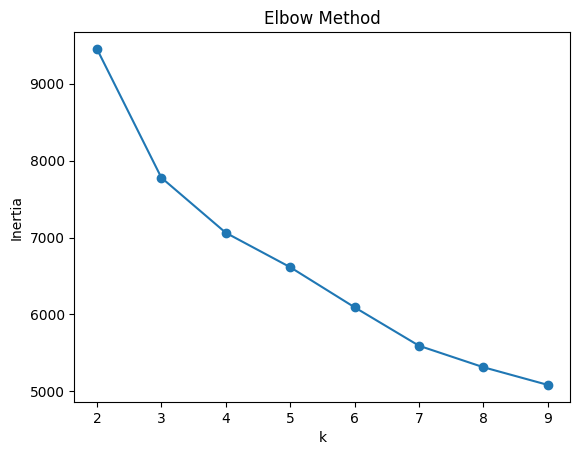

In [14]:
from sklearn_extra.cluster import KMedoids

kmedoids = KMedoids(
    n_clusters=4,
    metric='manhattan',
    random_state=42
)

inertia = []

for k in range(2, 10):
    model = KMedoids(
        n_clusters=k,
        metric='manhattan',
        random_state=42
    )
    model.fit(rfm_scaled)
    inertia.append(model.inertia_)

plt.plot(range(2,10), inertia, marker='o')
plt.title("Elbow Method")
plt.xlabel("k")
plt.ylabel("Inertia")
plt.show()

One can not see any obvious "elbow" in inertia curve, but the change rate saturates for k > 4, so we take k = 4 in this investigation.

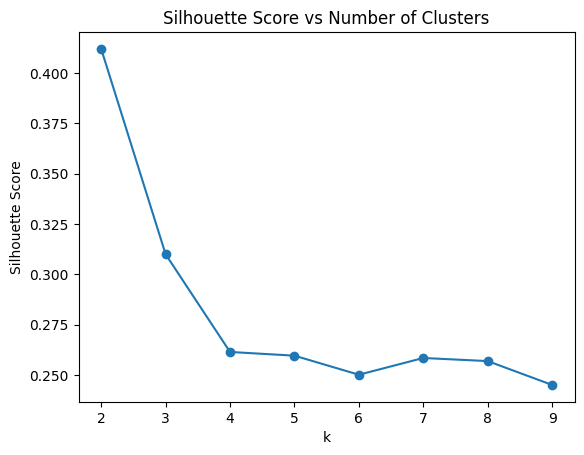

In [15]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

scores = []

for k in range(2, 10):
    model = KMedoids(
        n_clusters=k,
        metric='manhattan',
        random_state=42
    )
    labels = model.fit_predict(rfm_scaled)
    
    score = silhouette_score(rfm_scaled, labels)
    scores.append(score)

import matplotlib.pyplot as plt

plt.plot(range(2,10), scores, marker='o')
plt.title("Silhouette Score vs Number of Clusters")
plt.xlabel("k")
plt.ylabel("Silhouette Score")
plt.show()

Although the Silhouette score is highest for k=2, this solution is overly coarse and not useful for business segmentation. For k ≥ 3, Silhouette values stabilize, indicating diminishing gains in cluster separation. Combined with inertia-based elbow analysis and density-based clustering (HDBSCAN), the most consistent and interpretable number of customer segments lies in the range of **4 clusters**.

## **Generate clusters with K-Medoids algorithm and interpret the groups.**

In [16]:
kmedoids = KMedoids(
        n_clusters=4,
        metric='manhattan',
        random_state=42
    )
rfm["KMedoids_Cluster"] = kmedoids.fit_predict(rfm_scaled)
print(rfm)

             Recency  Frequency  Monetary  KMedoids_Cluster
Customer ID                                                
12346            326         12  77556.46                 3
12347              2          8   5633.32                 3
12348             75          5   2019.40                 2
12349             19          4   4428.69                 2
12350            310          1    334.40                 1
...              ...        ...       ...               ...
18283              4         22   2736.65                 3
18284            432          1    461.68                 1
18285            661          1    427.00                 1
18286            477          2   1296.43                 1
18287             43          7   4182.99                 2

[5878 rows x 4 columns]


In [17]:
cluster_means = rfm.groupby("KMedoids_Cluster")[["Recency", "Frequency", "Monetary"]].mean()
print(cluster_means)

                     Recency  Frequency      Monetary
KMedoids_Cluster                                     
0                 138.697674   2.934517    918.136526
1                 391.453777   1.300199    379.095274
2                 107.310912   6.834828   2561.147328
3                  28.646532  22.833333  13482.817983


## **Categorize customer clusters.**

* **Cluster k = 1:** worst segment
  * Recency $\approx$ 391 (very high, thus inactive)
  * Frequency $\approx$ 1.3 (very low)
  * Monetary $\approx$ 379 (low)<br/>
    
  The customers in this cluster haven't purchased in a long time, almost never buy and show low value. So these are **Lost/Churned customers**.
* **Cluster k = 0:** low activity
  * Recency $\approx$ 138
  * Frequency $\approx$ 3
  * Monetary $\approx$ 918

  The customers are somewhat inactive, are occasional buyers and and show low to medium value. So these are **At-risk / low-engagement customers**.
* **Cluster k = 2:** good customers
  * Recency $\approx$ 107
  * Frequency $\approx$ 6.8
  * Monetary $\approx$ 2561

  The customers are fairly recent, regular buyers with good spending. So these are **Regular / loyal customers**.
* **Cluster k = 3:** best customers
  * Recency $\approx$ 28 (very recent)
  * Frequency $\approx$ 22.8 (very high)
  * Monetary $\approx$ 13482 (very high)<br/>
  
  The customers are presently active, extremely active buyers with very high spends. These are **VIP / Champions customers**.

## **Conlcusions.**
The K-Medoids clustering based on RFM features revealed **four distinct customer segments** ranging from inactive customers to high-value VIP customers. The segmentation shows a strong gradient in customer value and engagement, where Cluster 3 represents highly active and profitable customers, while Cluster 1 represents churned or inactive users. Intermediate clusters capture at-risk and loyal customer groups. These segments provide actionable insights for targeted marketing strategies, including churn prevention, customer reactivation, and value maximization through personalized engagement.